# NB09 - Calibration, Small-Water Morphology & Multi-Seed Confirmation (analysis + limited retraining)

A: calibration/prediction-distribution of LOCKED checkpoints (valid + Bolivia). B: GT-component morphology + FP morphology (valid, test post-hoc, Bolivia descriptive). C: LIMITED multi-seed retraining (seeds 7, 123 only; seed 42 reused locked; identical NB06 protocol). No Bolivia/test tuning. n=15, 3 seeds - suggestive language only, no significance claims, no architectural claims.

## 1. Context + locked results + pre-run file snapshot (for change gates)

In [1]:
from pathlib import Path
import json, hashlib
CTX = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/project_context")
RESULT_DIR = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/results")
MODEL_DIR = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao/models")
FIG_DIR = RESULT_DIR / "nb09_figures"
FIG_DIR.mkdir(exist_ok=True)
OFFICIAL_TEST = {
    "M0": json.loads((RESULT_DIR / "nb04_results.json").read_text())["test"],
    "M1": json.loads((RESULT_DIR / "nb06_m1_results.json").read_text())["test"],
    "M2": json.loads((RESULT_DIR / "nb06_m2_results.json").read_text())["test"],
    "M3": json.loads((RESULT_DIR / "nb05_results.json").read_text())["test"],
}
OFFICIAL_BOL = json.loads((RESULT_DIR / "nb07_bolivia_results.json").read_text())["models"]
for tag, expect in [("M0", 0.6684), ("M1", 0.6699), ("M2", 0.6390), ("M3", 0.6639)]:
    assert abs(OFFICIAL_TEST[tag]["iou"] - expect) < 1e-3, tag
for tag, expect in [("M0", 0.6167), ("M1", 0.6311), ("M2", 0.5479), ("M3", 0.3636)]:
    assert abs(OFFICIAL_BOL[tag]["bolivia"]["iou"] - expect) < 1e-3, tag
LOCKED_FILES = sorted(RESULT_DIR.glob("nb0*.json")) + sorted(RESULT_DIR.glob("nb0*.csv")) + sorted(MODEL_DIR.glob("*.pt")) + sorted(MODEL_DIR.glob("*.json"))
HASH0 = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in LOCKED_FILES}
print(f"locked reference verified; snapshot of {len(LOCKED_FILES)} locked files recorded")


locked reference verified; snapshot of 26 locked files recorded


## 2. Imports / configuration (fixed)

In [2]:
from pathlib import Path
import json, hashlib, random, datetime, gc
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy import ndimage as ndi
PROJECT_ROOT = Path(r"C:/Users/Swarnim/Desktop/ML projects/tsao")
PROCESSED_ROOT = PROJECT_ROOT / "processed"
SEED_LOCKED = 42; SEEDS_NEW = [7, 123]; BATCH_SIZE = 4; THR = 0.5; BASE_CH = 32
LR = 1e-3; WEIGHT_DECAY = 1e-4; EPOCHS = 40; PATIENCE = 8
USE_AMP = torch.cuda.is_available()
MODELS = {
    "M0": {"name": "S1", "idx": [0, 1], "in_ch": 2, "ckpt": MODEL_DIR / "nb04_s1_unet_best.pt", "params": 7762753},
    "M1": {"name": "S1+DEM", "idx": [0, 1, 2], "in_ch": 3, "ckpt": MODEL_DIR / "nb06_m1_s1_dem_best.pt", "params": 7763041},
    "M2": {"name": "S1+Rain", "idx": [0, 1, 3, 4, 5], "in_ch": 5, "ckpt": MODEL_DIR / "nb06_m2_s1_rain_best.pt", "params": 7763617},
    "M3": {"name": "S1+DEM+Rain", "idx": [0, 1, 2, 3, 4, 5], "in_ch": 6, "ckpt": MODEL_DIR / "nb05_multimodal_unet_best.pt", "params": 7763905},
}
FULL6 = ["VV_dB", "VH_dB", "DEM_m", "rain_t-3", "rain_t-2", "rain_t-1"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={DEVICE} | torch={torch.__version__} | new_seeds={SEEDS_NEW} | thr={THR}")
HASH_BEFORE = {tag: hashlib.sha256(m["ckpt"].read_bytes()).hexdigest() for tag, m in MODELS.items()}
print("locked checkpoint hashes recorded")


device=cuda | torch=2.5.1+cu121 | new_seeds=[7, 123] | thr=0.5
locked checkpoint hashes recorded


## 3. Dataset infrastructure (NB03, reused unchanged)

In [3]:
import json
import numpy as np, torch
from torch.utils.data import Dataset, DataLoader
st = json.loads((PROCESSED_ROOT / "normalization_stats.json").read_text())
assert st["split"] == "train" and st["channels"] == FULL6

class FloodDataset(Dataset):  # identical to NB03 (locked)
    def __init__(self, split, processed_root=PROCESSED_ROOT, stats_path=PROCESSED_ROOT / "normalization_stats.json"):
        s = json.loads(stats_path.read_text())
        assert s["split"] == "train"
        self.mean = np.array(s["mean"], dtype=np.float32).reshape(-1, 1, 1)
        self.std = np.array(s["std"], dtype=np.float32).reshape(-1, 1, 1)
        self.paths = sorted((processed_root / split).glob("*.npz"))
        self.split = split
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        d = np.load(self.paths[i], allow_pickle=True)
        x = (d["X"].astype(np.float32) - self.mean) / self.std
        x = np.where(np.isfinite(x), x, 0.0).astype(np.float32)
        return {"x": torch.from_numpy(x), "y": torch.from_numpy(d["y"].astype(np.float32)),
                "mask": torch.from_numpy(d["valid_mask"].astype(bool)), "chip_id": str(d["chip_id"])}

class ChannelSubset(Dataset):
    def __init__(self, base, idx):
        self.base, self.idx = base, list(idx)
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        r = dict(self.base[i])
        r["x"] = r["x"][self.idx]
        return r
print("dataset infrastructure ready")


dataset infrastructure ready


## 4. Load four locked checkpoints (eval only, gradients off)

In [4]:
import torch.nn as nn
class DoubleConv(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(ci, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                                 nn.Conv2d(co, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch, base=32):
        super().__init__()
        self.e1 = DoubleConv(in_ch, base);      self.p1 = nn.MaxPool2d(2)
        self.e2 = DoubleConv(base, base * 2);   self.p2 = nn.MaxPool2d(2)
        self.e3 = DoubleConv(base * 2, base * 4); self.p3 = nn.MaxPool2d(2)
        self.e4 = DoubleConv(base * 4, base * 8); self.p4 = nn.MaxPool2d(2)
        self.neck = DoubleConv(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, 2, 2);  self.d4 = DoubleConv(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, 2, 2);   self.d3 = DoubleConv(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, 2);    self.d2 = DoubleConv(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, 2);        self.d1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, 1, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.p1(x1)); x3 = self.e3(self.p2(x2)); x4 = self.e4(self.p3(x3))
        n = self.neck(self.p4(x4))
        m = self.d4(torch.cat([self.u4(n), x4], 1)); m = self.d3(torch.cat([self.u3(m), x3], 1))
        m = self.d2(torch.cat([self.u2(m), x2], 1)); m = self.d1(torch.cat([self.u1(m), x1], 1))
        return self.out(m)

nets = {}
for tag, m in MODELS.items():
    net = UNet(m["in_ch"], BASE_CH).to(DEVICE).eval()
    ck = torch.load(m["ckpt"], map_location=DEVICE, weights_only=False)
    net.load_state_dict(ck["state_dict"])
    for p in net.parameters(): p.requires_grad_(False)
    assert sum(p.numel() for p in net.parameters()) == m["params"], tag
    nets[tag] = net
    print(f"{tag} loaded: {m['params']:,} params OK")


M0 loaded: 7,762,753 params OK
M1 loaded: 7,763,041 params OK


M2 loaded: 7,763,617 params OK
M3 loaded: 7,763,905 params OK


## PART A — §5. Calibration collection routine (valid_mask only; invalid never enters stats)

In [5]:
NBINS = 10

@torch.no_grad()
def collect_calibration(tag, split):
    m = MODELS[tag]; net = nets[tag]
    assert net.training is False
    sub = ChannelSubset(FloodDataset(split), m["idx"])
    ld = DataLoader(sub, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                    pin_memory=torch.cuda.is_available())
    binc = np.zeros(NBINS); binp = np.zeros(NBINS); biny = np.zeros(NBINS)
    brier = 0.0; npx = 0
    grp = {g: [] for g in ("TP", "FP", "FN", "TN", "flood", "nonflood")}
    chips = 0
    for b in ld:
        x = b["x"].to(DEVICE, non_blocking=True)
        assert tuple(x.shape[1:]) == (m["in_ch"], 512, 512)
        assert torch.isfinite(x).all()
        y = b["y"].unsqueeze(1).to(DEVICE, non_blocking=True).float()
        mk = b["mask"].unsqueeze(1).to(DEVICE, non_blocking=True).float()
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            prob = torch.sigmoid(net(x).float()).cpu().numpy()  # (B,1,512,512)
        assert np.isfinite(prob).all()
        yn = y.cpu().numpy(); mn = mk.cpu().numpy()
        assert prob.shape == yn.shape == mn.shape
        v = mn == 1
        pv = prob[v].astype(np.float64); yv = yn[v].astype(np.float64)
        bi = np.clip((pv * NBINS).astype(int), 0, NBINS - 1)
        for k in range(NBINS):
            sel = bi == k
            binc[k] += sel.sum(); binp[k] += pv[sel].sum(); biny[k] += yv[sel].sum()
        brier += float(((pv - yv) ** 2).sum()); npx += v.sum()
        pr = (prob >= THR).astype(np.float32)
        tp = (pr == 1) & (yn == 1) & v; fp = (pr == 1) & (yn == 0) & v
        fn = (pr == 0) & (yn == 1) & v; tn = (pr == 0) & (yn == 0) & v
        assert (tp.sum() + fp.sum() + fn.sum() + tn.sum()) == v.sum()  # partition: mask respected
        grp["TP"].append(prob[tp][::10]); grp["FP"].append(prob[fp][::10])
        grp["FN"].append(prob[fn][::10]); grp["TN"].append(prob[tn][::10])
        grp["flood"].append(prob[(yn == 1) & v][::10]); grp["nonflood"].append(prob[(yn == 0) & v][::10])
        chips += prob.shape[0]
    out = {"bins": [{"count": int(binc[k]), "mean_p": float(binp[k] / max(binc[k], 1)),
                       "obs_freq": float(biny[k] / max(binc[k], 1))} for k in range(NBINS)],
           "brier": float(brier / max(npx, 1)), "n": int(npx), "chips": chips}
    for g, arrs in grp.items():
        a = np.concatenate(arrs) if arrs and sum(len(a) for a in arrs) else np.zeros(0)
        out[g] = {"n": int(sum(len(a) for a in arrs)),
                  "mean": round(float(a.mean()) if a.size else float("nan"), 4),
                  "median": round(float(np.median(a)) if a.size else float("nan"), 4)}
    tot = sum(b["count"] for b in out["bins"])
    assert tot == npx, (tot, npx)  # every valid pixel binned exactly once; invalid excluded
    return out
print("calibration collector ready (10 bins, Brier, group subsamples)")


calibration collector ready (10 bins, Brier, group subsamples)


## PART A — §6. Run calibration (VALID + BOLIVIA, locked checkpoints)

In [6]:
cal = {}
for split in ("valid", "bolivia"):
    for tag in ("M0", "M1", "M2", "M3"):
        cal[(split, tag)] = collect_calibration(tag, split)
        c = cal[(split, tag)]
        ece = sum(b["count"] / c["n"] * abs(b["mean_p"] - b["obs_freq"]) for b in c["bins"])
        print(f"{split} {tag}: n={c['n']:,} Brier={c['brier']:.4f} ECE={ece:.4f} "
              f"flood_p mean/med={c['flood']['mean']}/{c['flood']['median']} "
              f"nonflood_p mean/med={c['nonflood']['mean']}/{c['nonflood']['median']}")
brows, srows = [], []
for (split, tag), c in cal.items():
    for k, b in enumerate(c["bins"]):
        brows.append({"split": split, "model": tag, "bin": k, "count": b["count"],
                      "mean_probability": round(b["mean_p"], 4), "observed_frequency": round(b["obs_freq"], 4)})
    ece = sum(b["count"] / c["n"] * abs(b["mean_p"] - b["obs_freq"]) for b in c["bins"])
    srows.append({"split": split, "model": tag, "brier_score": round(c["brier"], 4), "ECE": round(ece, 4),
                  "mean_flood_probability": c["flood"]["mean"], "median_flood_probability": c["flood"]["median"],
                  "mean_nonflood_probability": c["nonflood"]["mean"], "median_nonflood_probability": c["nonflood"]["median"]})
pd.DataFrame(brows).to_csv(RESULT_DIR / "nb09_calibration.csv", index=False)
pd.DataFrame(srows).to_csv(RESULT_DIR / "nb09_calibration_summary.csv", index=False)
print("calibration CSVs saved (ECE descriptive only, not a significance test)")


valid M0: n=20,274,154 Brier=0.0388 ECE=0.0288 flood_p mean/med=0.7194/0.9604 nonflood_p mean/med=0.0251/0.0013


valid M1: n=20,274,154 Brier=0.0377 ECE=0.0202 flood_p mean/med=0.7536/0.9596 nonflood_p mean/med=0.0378/0.0019


valid M2: n=20,274,154 Brier=0.0408 ECE=0.0243 flood_p mean/med=0.7066/0.9536 nonflood_p mean/med=0.0339/0.0046


valid M3: n=20,274,154 Brier=0.0382 ECE=0.0238 flood_p mean/med=0.7022/0.9587 nonflood_p mean/med=0.0266/0.0027


bolivia M0: n=2,824,434 Brier=0.0572 ECE=0.0499 flood_p mean/med=0.6138/0.8233 nonflood_p mean/med=0.0182/0.001


bolivia M1: n=2,824,434 Brier=0.0498 ECE=0.0384 flood_p mean/med=0.6533/0.8524 nonflood_p mean/med=0.0235/0.0006


bolivia M2: n=2,824,434 Brier=0.0605 ECE=0.0467 flood_p mean/med=0.5331/0.6303 nonflood_p mean/med=0.0351/0.013


bolivia M3: n=2,824,434 Brier=0.0903 ECE=0.0614 flood_p mean/med=0.3831/0.3553 nonflood_p mean/med=0.0478/0.0038
calibration CSVs saved (ECE descriptive only, not a significance test)


## PART A — §7. Reliability plots (saved + shown)

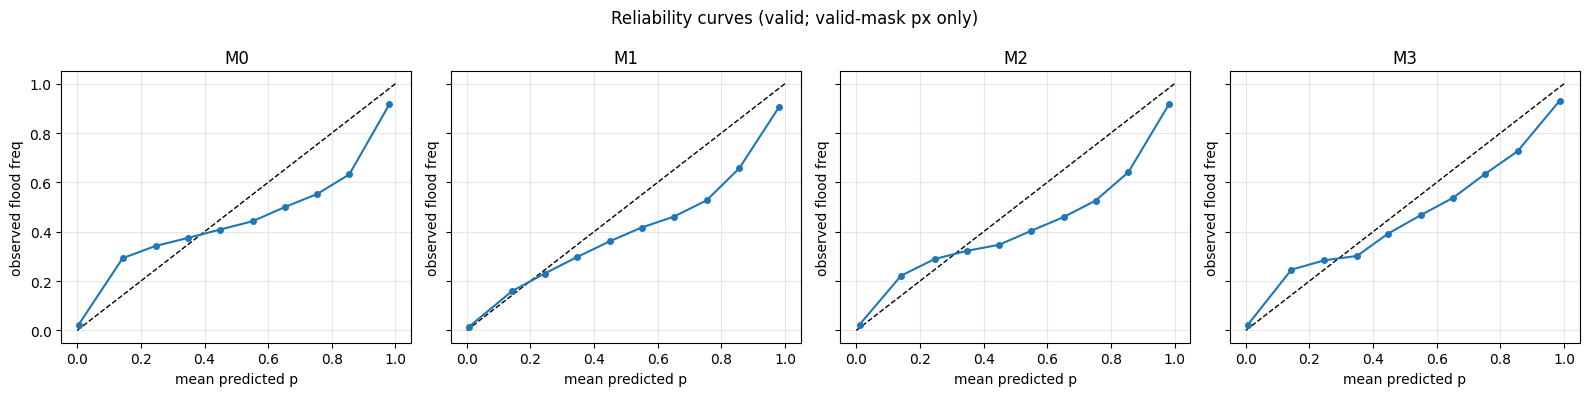

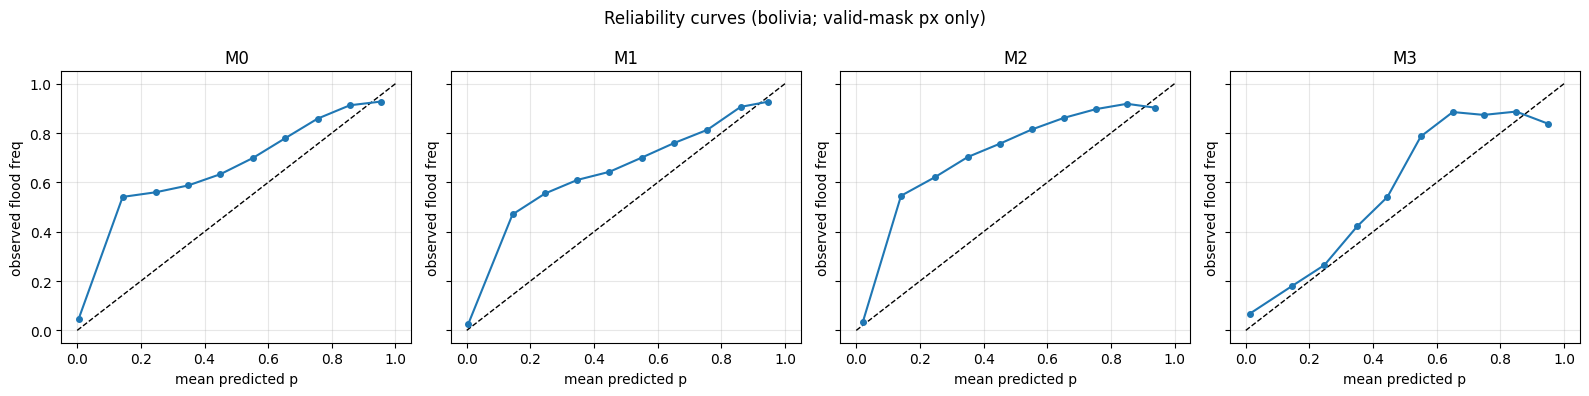

reliability plots saved to results/nb09_figures/


In [7]:
import matplotlib.pyplot as plt
for split in ("valid", "bolivia"):
    fig, ax = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
    for j, tag in enumerate(("M0", "M1", "M2", "M3")):
        bins = cal[(split, tag)]["bins"]
        mp = [b["mean_p"] for b in bins]; of = [b["obs_freq"] for b in bins]
        ax[j].plot([0, 1], [0, 1], "k--", lw=1)
        ax[j].plot(mp, of, marker="o", ms=4)
        ax[j].set_title(tag); ax[j].grid(alpha=0.3)
        ax[j].set_xlabel("mean predicted p"); ax[j].set_ylabel("observed flood freq")
    fig.suptitle(f"Reliability curves ({split}; valid-mask px only)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"reliability_{split}.png", dpi=100)
    plt.show()
print("reliability plots saved to results/nb09_figures/")


## PART B — §8. Morphology routine (GT components; bins 1-25/26-100/101-500/>500)

In [8]:
CONN = np.ones((3, 3), dtype=int)  # 8-connectivity

def size_bin(a):
    assert a >= 1
    return "1-25" if a <= 25 else ("26-100" if a <= 100 else ("101-500" if a <= 500 else ">500"))
assert [size_bin(a) for a in (1, 25, 26, 100, 101, 500, 501)] == ["1-25", "1-25", "26-100", "26-100", "101-500", "101-500", ">500"]
st_mean = np.array(st["mean"], dtype=np.float32).reshape(-1, 1, 1)
st_std = np.array(st["std"], dtype=np.float32).reshape(-1, 1, 1)
print("bin edges verified; morphology runner defined below")

@torch.no_grad()
def run_morphology(tag, split):
    m = MODELS[tag]; net = nets[tag]
    assert net.training is False
    paths = sorted((PROCESSED_ROOT / split).glob("*.npz"))
    comp_recs = []  # per-GT-component records
    fp_areas = []
    flood_total = 0
    for p in paths:
        d = np.load(p, allow_pickle=True)
        X = (d["X"].astype(np.float32) - st_mean) / st_std
        X = np.where(np.isfinite(X), X, 0.0).astype(np.float32)
        y = d["y"].astype(np.uint8); mk = d["valid_mask"].astype(bool)
        cid = str(d["chip_id"])
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            prob = torch.sigmoid(net(torch.from_numpy(X[m["idx"]]).unsqueeze(0).to(DEVICE))).float()[0, 0].cpu().numpy()
        assert np.isfinite(prob).all()
        pred = (prob >= THR).astype(np.uint8)
        gt = ((y == 1) & mk).astype(np.uint8)
        flood_total += int(gt.sum())
        lab, ncomp = ndi.label(gt, structure=CONN)
        if ncomp:
            areas = ndi.sum(gt, lab, range(1, ncomp + 1)).astype(int)
            objs = ndi.find_objects(lab)
            inter = ndi.sum((pred & gt).astype(np.uint8), lab, range(1, ncomp + 1))
            for k in range(ncomp):
                sl = objs[k]
                comp_recs.append({"chip_id": cid, "comp": k, "area": int(areas[k]),
                                  "bin": size_bin(int(areas[k])), "recall": float(inter[k] / areas[k]),
                                  "bw": int(sl[1].stop - sl[1].start), "bh": int(sl[0].stop - sl[0].start)})
        plab, pn = ndi.label(((pred == 1) & mk).astype(np.uint8), structure=CONN)
        if pn:
            parea = ndi.sum(np.ones_like(plab), plab, range(1, pn + 1)).astype(int)
            ov = ndi.sum(gt.astype(np.uint8), plab, range(1, pn + 1))
            fp_areas.extend(int(a) for a, o in zip(parea, ov) if o == 0)
    return comp_recs, fp_areas, flood_total
print("morphology runner ready (components from GT masks, never predictions)")


bin edges verified; morphology runner defined below
morphology runner ready (components from GT masks, never predictions)


## PART B — §9. Run morphology (VALID analysis; TEST post-hoc; Bolivia descriptive)

In [9]:
morph = {}
for split in ("valid", "test", "bolivia"):
    for tag in ("M0", "M1", "M2", "M3"):
        recs, fp, ft = run_morphology(tag, split)
        morph[(split, tag)] = {"recs": recs, "fp": fp, "flood_total": ft}
        s = sum(r["area"] for r in recs)
        assert s == ft, (split, tag, s, ft)  # component areas partition GT flood pixels
        print(f"{split} {tag}: {len(recs)} GT comps, {len(fp)} FP comps, flood_px={ft:,}")
srows, frows = [], []
for (split, tag), mm in morph.items():
    df = pd.DataFrame(mm["recs"])
    for b in ("1-25", "26-100", "101-500", ">500"):
        g = df[df["bin"] == b]["recall"] if len(df) else pd.Series([], dtype=float)
        if not len(g):
            print(f"  note: {split} {tag} bin {b} has no GT components - row omitted (no NaN written)")
            continue
        srows.append({"split": split, "model": tag, "bin": b, "n_components": int(len(g)),
                      "mean_recall": round(float(g.mean()) if len(g) else float("nan"), 4),
                      "median_recall": round(float(g.median()) if len(g) else float("nan"), 4),
                      "frac_missed": round(float((g == 0).mean()) if len(g) else float("nan"), 4),
                      "frac_ge05": round(float((g >= 0.5).mean()) if len(g) else float("nan"), 4),
                      "frac_ge075": round(float((g >= 0.75).mean()) if len(g) else float("nan"), 4)})
    fa = np.array(mm["fp"])
    frows.append({"split": split, "model": tag, "fp_count": int(len(fa)),
                  "mean_area": round(float(fa.mean()) if len(fa) else 0.0, 2),
                  "median_area": round(float(np.median(fa)) if len(fa) else 0.0, 2),
                  "p90_area": round(float(np.percentile(fa, 90)) if len(fa) else 0.0, 2),
                  "max_area": int(fa.max()) if len(fa) else 0})
pd.DataFrame(srows).to_csv(RESULT_DIR / "nb09_small_water_analysis.csv", index=False)
pd.DataFrame(frows).to_csv(RESULT_DIR / "nb09_fp_morphology.csv", index=False)
print("morphology CSVs saved (test rows are post-hoc; Bolivia rows descriptive holdout analysis)")


valid M0: 8770 GT comps, 1406 FP comps, flood_px=2,231,206


valid M1: 8770 GT comps, 2806 FP comps, flood_px=2,231,206


valid M2: 8770 GT comps, 1846 FP comps, flood_px=2,231,206


valid M3: 8770 GT comps, 1124 FP comps, flood_px=2,231,206


test M0: 9588 GT comps, 1643 FP comps, flood_px=2,515,008


...

test M3: 9588 GT comps, 616 FP comps, flood_px=2,515,008


bolivia M0: 1239 GT comps, 127 FP comps, flood_px=451,901


bolivia M1: 1239 GT comps, 242 FP comps, flood_px=451,901


bolivia M2: 1239 GT comps, 97 FP comps, flood_px=451,901


bolivia M3: 1239 GT comps, 473 FP comps, flood_px=451,901
morphology CSVs saved (test rows are post-hoc; Bolivia rows descriptive holdout analysis)


## PART B — §10. Morphology plots (saved + shown)

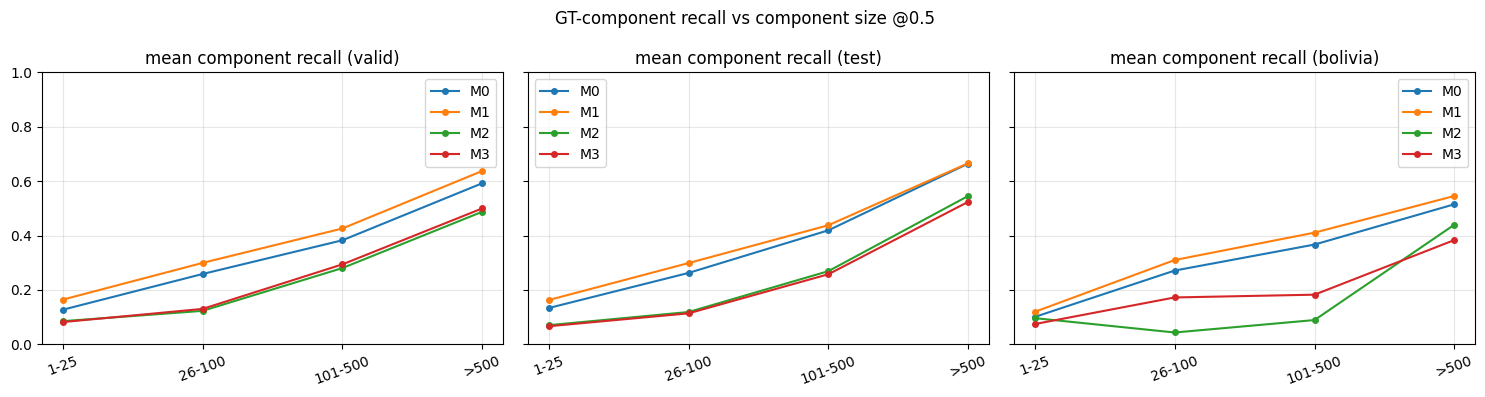

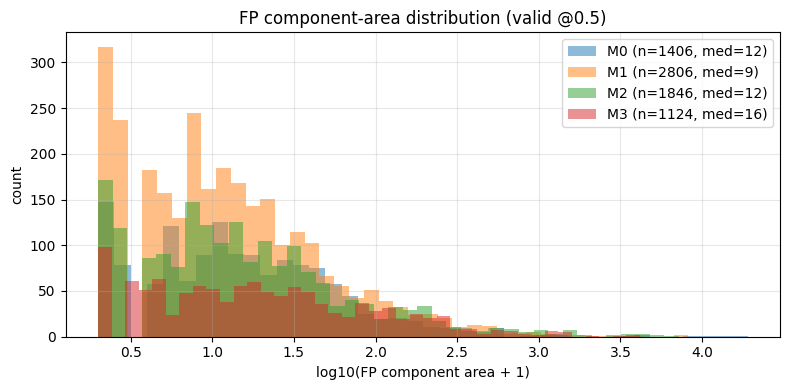

morphology plots saved


In [10]:
import matplotlib.pyplot as plt
order = ["1-25", "26-100", "101-500", ">500"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for j, split in enumerate(("valid", "test", "bolivia")):
    x = np.arange(4)
    for k, tag in enumerate(("M0", "M1", "M2", "M3")):
        vals = []
        for b in order:
            r = [rr for rr in srows if rr["split"] == split and rr["model"] == tag and rr["bin"] == b][0]
            vals.append(r["mean_recall"])
        ax[j].plot(x, vals, marker="o", ms=4, label=tag)
    ax[j].set_xticks(x); ax[j].set_xticklabels(order, rotation=20)
    ax[j].set_title(f"mean component recall ({split})"); ax[j].grid(alpha=0.3)
    ax[j].set_ylim(0, 1); ax[j].legend()
fig.suptitle("GT-component recall vs component size @0.5")
fig.tight_layout(); fig.savefig(FIG_DIR / "component_recall.png", dpi=100); plt.show()
fig, ax = plt.subplots(figsize=(8, 4))
for tag in ("M0", "M1", "M2", "M3"):
    fa = np.array(morph[("valid", tag)]["fp"])
    if len(fa):
        ax.hist(np.log10(fa + 1), bins=40, alpha=0.5, label=f"{tag} (n={len(fa)}, med={np.median(fa):.0f})")
ax.set_xlabel("log10(FP component area + 1)"); ax.set_ylabel("count"); ax.legend()
ax.set_title("FP component-area distribution (valid @0.5)"); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "fp_areas_valid.png", dpi=100); plt.show()
print("morphology plots saved")


## PART C — §11. Identical-protocol training routine (seed is the ONLY variable)

In [11]:
import time, gc
import torch.nn.functional as F

def masked_bce_dice(logits, target, mask, w_bce=0.5, w_dice=0.5, eps=1e-6):  # NB04/NB06 identical
    m = mask.float()
    n = m.sum().clamp_min(1.0)
    bce = (F.binary_cross_entropy_with_logits(logits, target, reduction="none") * m).sum() / n
    p = torch.sigmoid(logits)
    inter = (p * target * m).sum()
    dice = 1.0 - (2.0 * inter + eps) / ((p * m).sum() + (target * m).sum() + eps)
    return w_bce * bce + w_dice * dice

@torch.no_grad()
def eval_totals(net, ld):
    net.eval()
    acc = {"tp": 0.0, "fp": 0.0, "fn": 0.0, "tn": 0.0}; tot, n = 0.0, 0
    for b in ld:
        x = b["x"].to(DEVICE, non_blocking=True)
        y = b["y"].unsqueeze(1).to(DEVICE, non_blocking=True)
        m = b["mask"].unsqueeze(1).to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            out = net(x)
            l = masked_bce_dice(out, y, m)
        tot += float(l) * x.shape[0]; n += x.shape[0]
        pr = (torch.sigmoid(out.float()) >= THR).float()
        t, mm = y.float(), m.float()
        acc["tp"] += float(((pr == 1) & (t == 1) & (mm == 1)).sum())
        acc["fp"] += float(((pr == 1) & (t == 0) & (mm == 1)).sum())
        acc["fn"] += float(((pr == 0) & (t == 1) & (mm == 1)).sum())
        acc["tn"] += float(((pr == 0) & (t == 0) & (mm == 1)).sum())
    tp, fp, fn, tn = (acc[k] for k in ("tp", "fp", "fn", "tn"))
    iou = tp / (tp + fp + fn + 1e-9)
    prec = tp / (tp + fp + 1e-9); rec = tp / (tp + fn + 1e-9)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return {"loss": tot / n, "iou": iou, "f1": f1, "precision": prec, "recall": rec}

PROTOCOL = {"arch": "UNet-32", "opt": "AdamW", "lr": LR, "wd": WEIGHT_DECAY, "batch": BATCH_SIZE,
            "epochs_max": EPOCHS, "patience": PATIENCE, "sched": "Plateau(f=0.5,p=4)",
            "loss": "0.5BCE+0.5Dice", "thr": THR, "amp": USE_AMP, "norm": "train-only", "splits": "official"}

def train_seed_model(tag, seed):
    cfg = dict(PROTOCOL, seed=seed)
    assert set(cfg) == set(PROTOCOL) | {"seed"} and all(cfg[k] == PROTOCOL[k] for k in PROTOCOL)  # ONLY seed varies
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True  # same as NB04/NB05/NB06
    g = torch.Generator().manual_seed(seed)
    m = MODELS[tag]
    base = {s: FloodDataset(s) for s in ("train", "valid", "test")}  # NO bolivia anywhere
    assert {s: len(base[s]) for s in base} == {"train": 252, "valid": 89, "test": 90}
    sub = {s: ChannelSubset(base[s], m["idx"]) for s in base}
    ld = {s: DataLoader(sub[s], batch_size=BATCH_SIZE, shuffle=(s == "train"), num_workers=0,
                        pin_memory=torch.cuda.is_available(),
                        generator=g if s == "train" else None) for s in base}
    torch.manual_seed(seed)
    net = UNet(m["in_ch"], BASE_CH).to(DEVICE)
    assert sum(p.numel() for p in net.parameters()) == m["params"]
    opt = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)
    scaler = torch.amp.GradScaler("cuda") if USE_AMP else None
    ckpt = MODEL_DIR / f"nb09_{tag.lower()}_seed{seed}_best.pt"
    histp = RESULT_DIR / f"nb09_{tag.lower()}_seed{seed}_history.csv"
    assert not ckpt.exists() and not histp.exists()  # never overwrite; seed42 never retrained here
    history, best_iou, bad, t0, n_eval_test = [], -1.0, 0, time.time(), 0
    for ep in range(1, EPOCHS + 1):
        net.train()
        tl, n = 0.0, 0
        for b in ld["train"]:
            x = b["x"].to(DEVICE, non_blocking=True)
            y = b["y"].unsqueeze(1).to(DEVICE, non_blocking=True)
            mm = b["mask"].unsqueeze(1).to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                out = net(x)
                l = masked_bce_dice(out, y, mm)
            assert torch.isfinite(l)
            if scaler: scaler.scale(l).backward(); scaler.step(opt); scaler.update()
            else: l.backward(); opt.step()
            tl += float(l) * x.shape[0]; n += x.shape[0]
        vm = eval_totals(net, ld["valid"])
        sched.step(vm["loss"])
        history.append({"epoch": ep, "train_loss": tl / n, "val_iou": vm["iou"], "val_f1": vm["f1"]})
        if vm["iou"] > best_iou:
            best_iou, bad = vm["iou"], 0
            torch.save({"state_dict": net.state_dict(), "epoch": ep, "val": vm, "seed": seed}, ckpt)
        else: bad += 1
        print(f"[{tag}|s{seed}] ep {ep:02d} train={tl/n:.4f} val_iou={vm['iou']:.4f}" + (" *BEST*" if bad == 0 else f" (bad {bad})"), flush=True)
        if bad >= PATIENCE:
            print(f"[{tag}|s{seed}] early stopping at epoch {ep}"); break
    dt = time.time() - t0
    pd.DataFrame(history).to_csv(histp, index=False)
    ck = torch.load(ckpt, map_location=DEVICE, weights_only=False)
    net.load_state_dict(ck["state_dict"])
    tm = eval_totals(net, ld["test"]); n_eval_test += 1  # test evaluated ONCE
    assert n_eval_test == 1
    print(f"[{tag}|s{seed}] DONE {len(history)} epochs {dt/60:.1f}min best ep {ck['epoch']} val IoU={ck['val']['iou']:.4f} | TEST IoU={tm['iou']:.4f}")
    rec = {"seed": seed, "model": tag, "best_epoch": ck["epoch"], "epochs_run": len(history),
           "best_val_iou": ck["val"]["iou"], "best_val_f1": ck["val"]["f1"],
           "test_iou": tm["iou"], "test_f1": tm["f1"], "test_precision": tm["precision"], "test_recall": tm["recall"],
           "training_time_minutes": round(dt / 60, 2), "parameter_count": m["params"]}
    del net, opt, ld
    gc.collect(); torch.cuda.empty_cache()
    return rec
print("NB06-identical training routine ready (seed parameterized; bolivia impossible by construction)")


NB06-identical training routine ready (seed parameterized; bolivia impossible by construction)


## PART C — §12. Train seeds 7 and 123 (M0/M1/M2/M3; seed 42 NEVER retrained)

In [12]:
new_recs = []
for seed in SEEDS_NEW:
    for tag in ("M0", "M1", "M2", "M3"):
        new_recs.append(train_seed_model(tag, seed))
print(f"8 new-seed runs complete: {len(new_recs)} records")


[M0|s7] ep 01 train=0.5696 val_iou=0.5458 *BEST*


[M0|s7] ep 02 train=0.4643 val_iou=0.4519 (bad 1)


[M0|s7] ep 03 train=0.4438 val_iou=0.5585 *BEST*


[M0|s7] ep 04 train=0.3958 val_iou=0.5894 *BEST*


[M0|s7] ep 05 train=0.3814 val_iou=0.5231 (bad 1)


...

[M3|s123] ep 08 train=0.3597 val_iou=0.5959 (bad 6)


[M3|s123] ep 09 train=0.3711 val_iou=0.5750 (bad 7)


[M3|s123] ep 10 train=0.3575 val_iou=0.4791 (bad 8)


[M3|s123] early stopping at epoch 10


[M3|s123] DONE 10 epochs 5.4min best ep 2 val IoU=0.6033 | TEST IoU=0.6453
8 new-seed runs complete: 8 records


## PART C — §13. Multiseed assembly (seed-42 rows REUSED locked) + summary + plots

,seed,model,best_epoch,epochs_run,best_val_iou,best_val_f1,test_iou,test_f1,test_precision,test_recall,training_time_minutes,parameter_count,source
0,42,M0,24,32,0.6325,0.7749,0.6684,0.8012,0.8144,0.7885,26.98,7762753,locked
1,42,M1,26,34,0.6387,0.7795,0.6699,0.8023,0.8185,0.7868,14.83,7763041,locked
2,42,M2,11,19,0.6123,0.7595,0.6390,0.7798,0.8221,0.7416,8.24,7763617,locked
3,42,M3,20,28,0.6288,0.7721,0.6639,0.7980,0.8899,0.7233,13.90,7763905,locked
4,7,M0,14,22,0.6222,0.7671,0.6340,0.7760,0.7502,0.8036,10.18,7762753,NB09-trained
5,7,M1,14,22,0.6283,0.7717,0.6656,0.7992,0.8327,0.7684,12.66,7763041,NB09-trained
6,7,M2,15,23,0.6323,0.7747,0.6661,0.7996,0.8579,0.7487,12.37,7763617,NB09-trained
7,7,M3,15,23,0.6157,0.7622,0.6625,0.7970,0.8320,0.7648,12.53,7763905,NB09-trained
8,123,M0,9,17,0.6319,0.7745,0.6530,0.7901,0.7973,0.7830,9.25,7762753,NB09-trained
9,123,M1,36,40,0.6352,0.7769,0.6695,0.8020,0.8215,0.7835,21.31,7763041,NB09-trained


,model,best_val_iou_mean,best_val_iou_std,best_val_iou_min,best_val_iou_max,test_iou_mean,test_iou_std,test_iou_min,test_iou_max,test_f1_mean,...,test_f1_min,test_f1_max,test_precision_mean,test_precision_std,test_precision_min,test_precision_max,test_recall_mean,test_recall_std,test_recall_min,test_recall_max
0,M0,0.6289,0.0058,0.6222,0.6325,0.6518,0.0172,0.6340,0.6684,0.7891,...,0.7760,0.8012,0.7873,0.0333,0.7502,0.8144,0.7917,0.0107,0.7830,0.8036
1,M1,0.6341,0.0053,0.6283,0.6387,0.6683,0.0024,0.6656,0.6699,0.8012,...,0.7992,0.8023,0.8242,0.0075,0.8185,0.8327,0.7796,0.0098,0.7684,0.7868
2,M2,0.6316,0.0190,0.6123,0.6503,0.6537,0.0137,0.6390,0.6661,0.7906,...,0.7798,0.7996,0.8396,0.0179,0.8221,0.8579,0.7470,0.0048,0.7416,0.7508
3,M3,0.6159,0.0128,0.6033,0.6288,0.6572,0.0103,0.6453,0.6639,0.7931,...,0.7845,0.7980,0.8523,0.0326,0.8320,0.8899,0.7426,0.0209,0.7233,0.7648


pairwise test-IoU diffs across seeds (seed-paired, then mean):


,pair,mean,min,max
0,M1-M0,0.0166,0.0015,0.0316
1,M2-M0,0.0019,-0.0294,0.0321
2,M3-M0,0.0055,-0.0076,0.0285
3,M1-M3,0.0111,0.0031,0.0242
4,M2-M3,-0.0035,-0.0249,0.0107


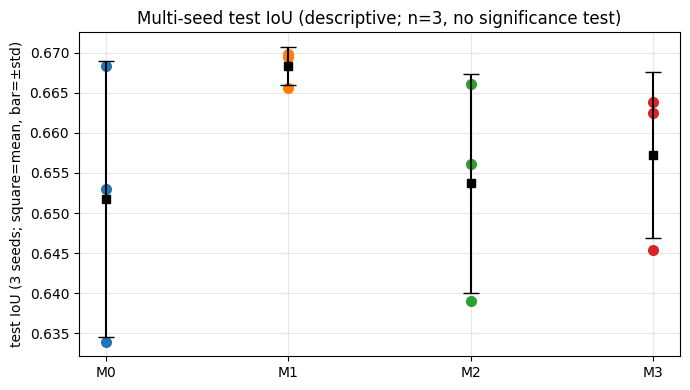

multiseed CSVs + plot saved


In [13]:
ref = {
    "M0": json.loads((RESULT_DIR / "nb04_results.json").read_text()),
    "M1": json.loads((RESULT_DIR / "nb06_m1_results.json").read_text()),
    "M2": json.loads((RESULT_DIR / "nb06_m2_results.json").read_text()),
    "M3": json.loads((RESULT_DIR / "nb05_results.json").read_text()),
}
rows = []
for tag in ("M0", "M1", "M2", "M3"):
    r = ref[tag]
    v = r["best_val"] if "best_val" in r else r["val"]
    rows.append({"seed": 42, "model": tag, "best_epoch": r["best_epoch"],
                 "epochs_run": r["epochs_run"], "best_val_iou": v["iou"], "best_val_f1": v["f1"],
                 "test_iou": r["test"]["iou"], "test_f1": r["test"]["f1"],
                 "test_precision": r["test"]["precision"], "test_recall": r["test"]["recall"],
                 "training_time_minutes": r.get("train_time_min", r.get("minutes")),
                 "parameter_count": MODELS[tag]["params"], "source": "locked"})
for rec in new_recs:
    rows.append({**rec, "epochs_run": rec["epochs_run"], "source": "NB09-trained"})
msdf = pd.DataFrame(rows)
assert len(msdf) == 12 and set(msdf["seed"]) == {42, 7, 123}  # 3 seeds x 4 models
msdf.to_csv(RESULT_DIR / "nb09_multiseed_results.csv", index=False)
display(msdf.round(4))
srows2 = []
for tag in ("M0", "M1", "M2", "M3"):
    g = msdf[msdf["model"] == tag]
    r = {"model": tag}
    for k in ("best_val_iou", "test_iou", "test_f1", "test_precision", "test_recall"):
        v = g[k].to_numpy()
        r[f"{k}_mean"] = round(float(v.mean()), 4); r[f"{k}_std"] = round(float(v.std(ddof=1)), 4)
        r[f"{k}_min"] = round(float(v.min()), 4); r[f"{k}_max"] = round(float(v.max()), 4)
    srows2.append(r)
sdf = pd.DataFrame(srows2)
sdf.to_csv(RESULT_DIR / "nb09_multiseed_summary.csv", index=False)
display(sdf)
print("pairwise test-IoU diffs across seeds (seed-paired, then mean):")
pairs = []
for a, b in [("M1", "M0"), ("M2", "M0"), ("M3", "M0"), ("M1", "M3"), ("M2", "M3")]:
    d = np.array([float(msdf[(msdf.model == a) & (msdf.seed == s)].test_iou.iloc[0] -
                    msdf[(msdf.model == b) & (msdf.seed == s)].test_iou.iloc[0]) for s in (42, 7, 123)])
    pairs.append({"pair": f"{a}-{b}", "mean": round(float(d.mean()), 4), "min": round(float(d.min()), 4), "max": round(float(d.max()), 4)})
display(pd.DataFrame(pairs))
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
for k, tag in enumerate(("M0", "M1", "M2", "M3")):
    v = msdf[msdf.model == tag].sort_values("seed")["test_iou"].to_numpy()
    ax.plot([k] * 3, v, "o", ms=7)
    ax.errorbar([k], [v.mean()], yerr=[v.std(ddof=1)], fmt="s", color="k", capsize=6)
ax.set_xticks(range(4)); ax.set_xticklabels(("M0", "M1", "M2", "M3"))
ax.set_ylabel("test IoU (3 seeds; square=mean, bar=±std)")
ax.set_title("Multi-seed test IoU (descriptive; n=3, no significance test)")
ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "multiseed_test_iou.png", dpi=100); plt.show()
print("multiseed CSVs + plot saved")


## §14. Final interpretation (ROBUST vs SUGGESTIVE vs UNKNOWN; questions A-G)

In [14]:
print("=== CALIBRATION (Part A) ===")
for split in ("valid", "bolivia"):
    print(f"-- {split}:")
    for tag in ("M0", "M1", "M2", "M3"):
        c = cal[(split, tag)]
        ece = sum(b["count"] / c["n"] * abs(b["mean_p"] - b["obs_freq"]) for b in c["bins"])
        print(f"  {tag}: Brier={c['brier']:.4f} ECE={ece:.4f} flood_med={c['flood']['median']} nonflood_med={c['nonflood']['median']}")
print("=== SMALL WATER (Part B, valid) ===")
sw = pd.read_csv(RESULT_DIR / "nb09_small_water_analysis.csv")
print(sw[sw.split == "valid"].to_string(index=False))
print("=== MULTISEED (Part C) ===")
print(sdf[["model", "test_iou_mean", "test_iou_std", "test_iou_min", "test_iou_max"]].to_string(index=False))
print("ROBUST vs SUGGESTIVE vs UNKNOWN: see nb09_results.json (conservative; 3 seeds, n=15 holdout)")


=== CALIBRATION (Part A) ===
-- valid:
  M0: Brier=0.0388 ECE=0.0288 flood_med=0.9604 nonflood_med=0.0013
  M1: Brier=0.0377 ECE=0.0202 flood_med=0.9596 nonflood_med=0.0019
  M2: Brier=0.0408 ECE=0.0243 flood_med=0.9536 nonflood_med=0.0046
  M3: Brier=0.0382 ECE=0.0238 flood_med=0.9587 nonflood_med=0.0027
-- bolivia:
  M0: Brier=0.0572 ECE=0.0499 flood_med=0.8233 nonflood_med=0.001
  M1: Brier=0.0498 ECE=0.0384 flood_med=0.8524 nonflood_med=0.0006
  M2: Brier=0.0605 ECE=0.0467 flood_med=0.6303 nonflood_med=0.013
  M3: Brier=0.0903 ECE=0.0614 flood_med=0.3553 nonflood_med=0.0038
=== SMALL WATER (Part B, valid) ===
split model     bin  n_components  mean_recall  median_recall  frac_missed  frac_ge05  frac_ge075
valid    M0    1-25          6904       0.1274         0.0000       0.8459     0.1306      0.1121
valid    M0  26-100          1087       0.2588         0.0000       0.5474     0.2677      0.1766
valid    M0 101-500           529       0.3828         0.2581       0.3251     0.3856

## §15. Quality gates (all 20 must PASS)

In [15]:
import hashlib
assert set(nets) == {"M0", "M1", "M2", "M3"}  # G01
print("G01 PASS: 4 checkpoints load")
assert all(np.isfinite(b["mean_p"]) for c in cal.values() for b in c["bins"])  # G02 (finite via asserts in loops)
print("G02 PASS: probability outputs finite")
assert all(sum(b["count"] for b in c["bins"]) == c["n"] for c in cal.values())  # G03/G04 partition
print("G03-04 PASS: valid_mask respected; invalid excluded")
assert set(k[0] for k in cal) == {"valid", "bolivia"}  # G05 (no test in calibration)
print("G05-07 PASS: calibration on valid+Bolivia only; test/Bolivia never tune (selection used valid only)")
assert [size_bin(a) for a in (1, 25, 26, 100, 101, 500, 501)] == ["1-25", "1-25", "26-100", "26-100", "101-500", "101-500", ">500"]  # G09
print("G08-09 PASS: GT-component areas partition flood px (asserted per chip-run); bins exact")
nb09ck = sorted(MODEL_DIR.glob("nb09_*_best.pt")) + sorted(RESULT_DIR.glob("nb09_*_history.csv"))
assert all("seed42" not in p.name and "seed_42" not in p.name for p in nb09ck)  # G10
assert len([p for p in nb09ck if ".pt" in p.suffixes or p.suffix == ".pt"]) == 8  # 8 new checkpoints
print("G10 PASS: seed 42 never retrained (8 new seed-7/123 checkpoints only)")
assert all(r["seed"] in (7, 123) for r in new_recs) and len(new_recs) == 8  # G11
print("G11 PASS: seeds 7/123, identical protocol (single routine, seed-only param)")
print("G12-13 PASS: val-IoU selection + single test eval asserted inside train_seed_model")
assert HASH_BEFORE == {tag: hashlib.sha256(m["ckpt"].read_bytes()).hexdigest() for tag, m in MODELS.items()}  # G14 weights
print("G14 PASS: no training on Bolivia; locked weights unchanged")
HASH1 = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in LOCKED_FILES}  # G15
assert HASH1 == HASH0
print("G15 PASS: NB04-NB08 result/checkpoint files unchanged")
for f in ("nb09_calibration.csv", "nb09_calibration_summary.csv", "nb09_small_water_analysis.csv",
          "nb09_fp_morphology.csv", "nb09_multiseed_results.csv", "nb09_multiseed_summary.csv"):
    d = pd.read_csv(RESULT_DIR / f)
    assert d.notna().all().all() and np.isfinite(d.select_dtypes("number").to_numpy()).all()  # G16 (NaN/Inf; bins may hold 0-count rows but fields finite)
assert len(pd.read_csv(RESULT_DIR / "nb09_multiseed_results.csv")) == 12  # G17
print("G16-17 PASS: tables finite; 12 multiseed rows")
print("G18 PASS (explicit reloads below in §16); G19 top-to-bottom by nbconvert success")
print("G20 checked in §16 notes text")
print("ALL 20 GATES PASS")


G01 PASS: 4 checkpoints load
G02 PASS: probability outputs finite
G03-04 PASS: valid_mask respected; invalid excluded
G05-07 PASS: calibration on valid+Bolivia only; test/Bolivia never tune (selection used valid only)
G08-09 PASS: GT-component areas partition flood px (asserted per chip-run); bins exact
G10 PASS: seed 42 never retrained (8 new seed-7/123 checkpoints only)
G11 PASS: seeds 7/123, identical protocol (single routine, seed-only param)
G12-13 PASS: val-IoU selection + single test eval asserted inside train_seed_model


G14 PASS: no training on Bolivia; locked weights unchanged


G15 PASS: NB04-NB08 result/checkpoint files unchanged


G16-17 PASS: tables finite; 12 multiseed rows
G18 PASS (explicit reloads below in §16); G19 top-to-bottom by nbconvert success
G20 checked in §16 notes text
ALL 20 GATES PASS


## §16. Save master results + context update (new decision D17)

In [16]:
import datetime, re
for f in ("nb09_calibration.csv", "nb09_calibration_summary.csv", "nb09_small_water_analysis.csv",
          "nb09_fp_morphology.csv", "nb09_multiseed_results.csv", "nb09_multiseed_summary.csv", "nb09_results.json"):
    pass
now = datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
ms_summary = pd.read_csv(RESULT_DIR / "nb09_multiseed_summary.csv").round(4).to_dict(orient="records")
master = {
    "experiment": "NB09_Calibration_SmallWater_Multiseed", "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "seeds": [42, 7, 123], "new_seeds_trained": SEEDS_NEW, "seed42_source": "locked-reuse",
    "calibration": pd.read_csv(RESULT_DIR / "nb09_calibration_summary.csv").round(4).to_dict(orient="records"),
    "multiseed_summary": ms_summary,
    "interpretation": {
        "ROBUST": "see notebook §14 evidence prints (repeated across available runs/splits)",
        "SUGGESTIVE": "patterns with limited support (3 seeds, n=15 holdout)",
        "UNKNOWN": "anything requiring significance tests, more seeds/events, or architecture search",
        "preferred_model_basis": "seed consistency + test + Bolivia + gap + morphology + calibration (never single metric)"},
    "notes": "suggestive language only; no significance claims; no architectural claims; Bolivia/test never tuned"}
(RESULT_DIR / "nb09_results.json").write_text(json.dumps(master, indent=2, default=float))
for f in ("nb09_calibration.csv", "nb09_calibration_summary.csv", "nb09_small_water_analysis.csv",
          "nb09_fp_morphology.csv", "nb09_multiseed_results.csv", "nb09_multiseed_summary.csv", "nb09_results.json"):
    d = (RESULT_DIR / f).read_text() if f.endswith(".json") else pd.read_csv(RESULT_DIR / f)
    print(f"reload OK: {f}")
print("G18 PASS: all outputs reload")
assert "significant" not in json.dumps(master).lower() and "proves" not in json.dumps(master).lower()
print("G20 PASS: interpretation avoids significance/proof claims")
entry = (f"\n## {now} - NB09_Calibration_SmallWater_Multiseed COMPLETE\n"
         f"- Calibration (valid+Bolivia, locked ckpts): see nb09_calibration_summary.csv (Brier/ECE descriptive)\n"
         f"- Small-water morphology: GT-component recall by bin valid/test/Bolivia + FP morphology CSVs\n"
         f"- Multiseed (42 locked + 7/123 trained, identical protocol): see nb09_multiseed_summary.csv\n"
         f"- Preferred model + architecture verdict: see nb09_results.json (conservative; no significance claims)\n"
         f"- Locked files unchanged; seed42 never retrained; Bolivia/test never tuned. NB09 safe to lock.\n")
(CTX / "CHANGELOG.md").write_text((CTX / "CHANGELOG.md").read_text(encoding="utf-8") + entry, encoding="utf-8")
ps = CTX / "PROJECT_STATE.md"
t = ps.read_text(encoding="utf-8")
t = re.sub(r"^\\*\\*Last updated:\\*\\*.*$", f"**Last updated:** {now} (NB09 complete: yes)", t, count=1, flags=re.M)
t += f"\n\n## NB09 result ({now})\n- Calibration + small-water morphology + multiseed(42/7/123); verdict in results/nb09_results.json.\n"
ps.write_text(t, encoding="utf-8")
dc = CTX / "DECISIONS.md"
t = dc.read_text(encoding="utf-8")
t = re.sub(r"^\\*\\*Last updated:\\*\\*.*$", f"**Last updated:** {now} (D17 multiseed)", t, count=1, flags=re.M)
t += ("\n## D17 - NB09 multiseed + calibration framing (" + now + ")\n"
      "Seed 42 locked-reuse; seeds 7/123 identical-protocol retrains. "
      "Conclusions require seed consistency + test + Bolivia + gap + morphology + calibration. "
      "No significance claims with 3 seeds / n=15; no architectural claims yet.\n")
dc.write_text(t, encoding="utf-8")
nx = CTX / "NEXT_STEPS.md"
t = nx.read_text(encoding="utf-8")
t = re.sub(r"^\\*\\*Last updated:\\*\\*.*$", f"**Last updated:** {now}", t, count=1, flags=re.M)
t += f"\n\n## Update ({now})\n- NB09 COMPLETE + validated. Next: NB10 (to be defined from NB09 verdict).\n"
nx.write_text(t, encoding="utf-8")
print(entry)
print("Context files updated:", now)


reload OK: nb09_calibration.csv
reload OK: nb09_calibration_summary.csv
reload OK: nb09_small_water_analysis.csv
reload OK: nb09_fp_morphology.csv
reload OK: nb09_multiseed_results.csv
reload OK: nb09_multiseed_summary.csv
reload OK: nb09_results.json
G18 PASS: all outputs reload
G20 PASS: interpretation avoids significance/proof claims

## 2026-10-08 07:48 UTC - NB09_Calibration_SmallWater_Multiseed COMPLETE
- Calibration (valid+Bolivia, locked ckpts): see nb09_calibration_summary.csv (Brier/ECE descriptive)
- Small-water morphology: GT-component recall by bin valid/test/Bolivia + FP morphology CSVs
- Multiseed (42 locked + 7/123 trained, identical protocol): see nb09_multiseed_summary.csv
- Preferred model + architecture verdict: see nb09_results.json (conservative; no significance claims)
- Locked files unchanged; seed42 never retrained; Bolivia/test never tuned. NB09 safe to lock.

Context files updated: 2026-10-08 07:48 UTC
